In [6]:
import torch
from torch import nn
from dataset import Rice2
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from torch.utils.data import Subset
from torch.optim.lr_scheduler import LambdaLR

from utility import plot_samples_gan, plot_losses, to_img, plot_test_samples
from losses import weighted_l1_loss, compute_ssim
from models import UNet

import time
import os

import numpy as np

from skimage.metrics import peak_signal_noise_ratio as psnr_fn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
import subprocess


def pick_freest_gpu():
    """Gibt den Index der GPU mit dem meisten freien Speicher zurück."""
    if not torch.cuda.is_available():
        return None
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.free", "--format=csv,nounits,noheader"]
        ).decode()
        free = [int(x) for x in out.strip().split("\n")]
        best = max(range(len(free)), key=lambda i: free[i])
        print(f"Freier Speicher pro GPU (MiB): {free} → wähle GPU {best}")
        return best
    except Exception as e:
        print(f"GPU-Abfrage fehlgeschlagen ({e}), nehme GPU 0")
        return 0


gpu = pick_freest_gpu()
device = torch.device(f"cuda:{gpu}" if gpu is not None else "cpu")

Freier Speicher pro GPU (MiB): [42803, 34010, 42487, 42487] → wähle GPU 0


In [8]:
# hyperparameter
num_epochs = 50
batch_size = 8
lr = 1e-4
use_masks = True  # Maske als zusätzlichen Generator-Input geben
save_last_n_samples = 3  # Sample-Bilder der letzten N Epochen speichern
plot_every = 10  # zusätzlich alle N Epochen ein Sample anzeigen
w_factor = 0.3  # Gewicht des maskierten L1-Terms
w_extra = 4.0  # Wolken-Extragewicht im maskierten L1
best_score = -1.0
best_psnr = -1.0

# in_channels: 3 (cloudy) + 1 (mask) falls use_masks
in_channels = 4 if use_masks else 3
generator = UNet(
    in_channels=in_channels, out_channels=3, feature_channels=64, depth=5
).to(device)

optimizer = Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))

decay_start = 100  # ab welcher Epoche der Decay einsetzt


def lr_lambda(epoch):
    if epoch < decay_start:
        return 1.0
    # ab decay_start linear von 1.0 auf 0.0 über die restlichen Epochen
    return max(0.0, 1.0 - (epoch - decay_start) / (num_epochs - decay_start))


scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

l1 = nn.L1Loss()

train_losses, val_losses = [], []
val_psnrs, val_ssims = [], []

data_dir = "/data/home/lec42675/cloud_removal/RICE_DATASET/RICE2"

# 1) Volles Dataset nur zur Bestimmung der Split-Indizes.
base_dataset = Rice2(data_dir, augment=False)
n_total = len(base_dataset)

n_train = int(0.64 * n_total)
n_val = int(0.16 * n_total)
n_test = n_total - n_train - n_val  # Rest, damit die Summe exakt aufgeht

# 2) Reproduzierbarer Split (fester Seed -> immer dieselbe Aufteilung).
split_generator = torch.Generator().manual_seed(42)
train_subset, val_subset, test_subset = random_split(
    base_dataset, [n_train, n_val, n_test], generator=split_generator
)
train_idx = train_subset.indices
val_idx = val_subset.indices
test_idx = test_subset.indices

# 3) Getrennte Dataset-Instanzen: Train augmentiert, Val/Test nicht.
train_data = Subset(Rice2(data_dir, augment=True), train_idx)
val_data = Subset(Rice2(data_dir, augment=False), val_idx)
test_data = Subset(Rice2(data_dir, augment=False), test_idx)

print(
    f"Gesamt: {n_total} | "
    f"Train: {len(train_data)} ({len(train_data)/n_total:.0%}) | "
    f"Val: {len(val_data)} ({len(val_data)/n_total:.0%}) | "
    f"Test: {len(test_data)} ({len(test_data)/n_total:.0%})"
)

# 4) DataLoader.
train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)
val_dataloader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)
test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

Gesamt: 736 | Train: 471 (64%) | Val: 117 (16%) | Test: 148 (20%)


In [9]:
plot_dataset = Rice2(data_dir, augment=False)

# gewünschte Dateinamen (passe die Endung an deine echten Dateien an!)
wanted_names = ["548.png", "449.png", "282.png", "111.png", "22.png"]

cloudy_list, label_list, mask_list = [], [], []
for name in wanted_names:
    pos = plot_dataset.ids.index(name)  # Position dieses Dateinamens finden
    c, l, m = plot_dataset[pos]
    cloudy_list.append(c)
    label_list.append(l)
    mask_list.append(m)

fixed_batch = (
    torch.stack(cloudy_list),
    torch.stack(label_list),
    torch.stack(mask_list),
)

/data/home/lec42675/.venv/gpu-env/lib/python3.10/site-packages/torchvision/transforms/v2/functional/_deprecated.py:12: UserWarning: The function `to_tensor(...)` is deprecated and will be removed in a future release. Instead, please use `to_image(...)` followed by `to_dtype(..., dtype=torch.float32, scale=True)`.
  warnings.warn(


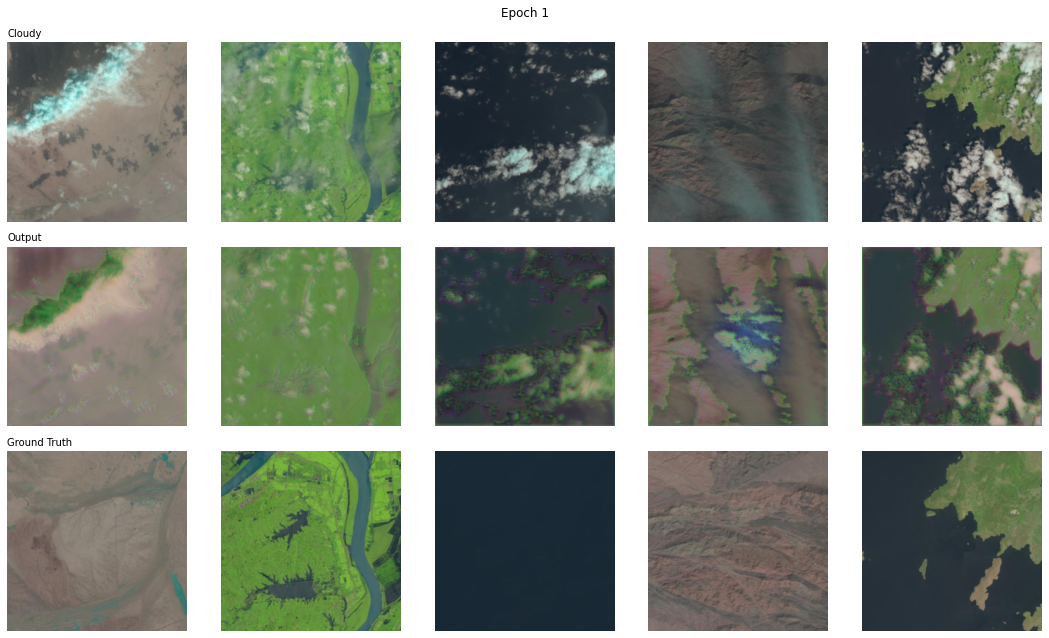

Epoch [1/50] | LR: 1.00e-04 L1: 0.472  0.321 | PSNR: 19.64 | SSIM: 0.6818
Epoch [2/50] | LR: 1.00e-04 L1: 0.311  0.366 | PSNR: 20.29 | SSIM: 0.7126
Epoch [3/50] | LR: 1.00e-04 L1: 0.287  0.273 | PSNR: 21.34 | SSIM: 0.7398
Epoch [4/50] | LR: 1.00e-04 L1: 0.251  0.177 | PSNR: 23.57 | SSIM: 0.7641
Epoch [5/50] | LR: 1.00e-04 L1: 0.250  0.194 | PSNR: 23.07 | SSIM: 0.6880
Epoch [6/50] | LR: 1.00e-04 L1: 0.220  0.213 | PSNR: 22.91 | SSIM: 0.7446
Epoch [7/50] | LR: 1.00e-04 L1: 0.225  0.160 | PSNR: 26.02 | SSIM: 0.8072
Epoch [8/50] | LR: 1.00e-04 L1: 0.234  0.176 | PSNR: 23.86 | SSIM: 0.7241
Epoch [9/50] | LR: 1.00e-04 L1: 0.233  0.137 | PSNR: 25.64 | SSIM: 0.7948
Epoch [10/50] | LR: 1.00e-04 L1: 0.197  0.195 | PSNR: 23.18 | SSIM: 0.7477


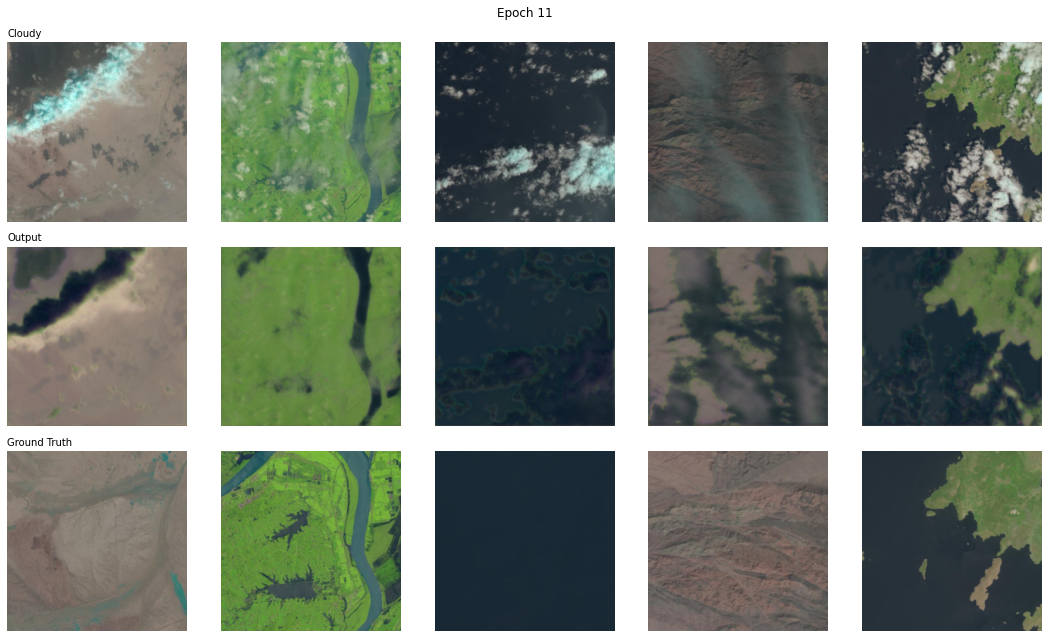

Epoch [11/50] | LR: 1.00e-04 L1: 0.203  0.135 | PSNR: 25.68 | SSIM: 0.8120
Epoch [12/50] | LR: 1.00e-04 L1: 0.185  0.205 | PSNR: 23.00 | SSIM: 0.7798
Epoch [13/50] | LR: 1.00e-04 L1: 0.184  0.142 | PSNR: 25.54 | SSIM: 0.7869
Epoch [14/50] | LR: 1.00e-04 L1: 0.186  0.122 | PSNR: 27.14 | SSIM: 0.8141
Epoch [15/50] | LR: 1.00e-04 L1: 0.173  0.128 | PSNR: 26.12 | SSIM: 0.8066
Epoch [16/50] | LR: 1.00e-04 L1: 0.158  0.142 | PSNR: 26.30 | SSIM: 0.8192
Epoch [17/50] | LR: 1.00e-04 L1: 0.155  0.145 | PSNR: 25.71 | SSIM: 0.7778
Epoch [18/50] | LR: 1.00e-04 L1: 0.149  0.140 | PSNR: 25.14 | SSIM: 0.8205
Epoch [19/50] | LR: 1.00e-04 L1: 0.153  0.739 | PSNR: 10.09 | SSIM: 0.6509
Epoch [20/50] | LR: 1.00e-04 L1: 0.173  0.126 | PSNR: 26.44 | SSIM: 0.8367


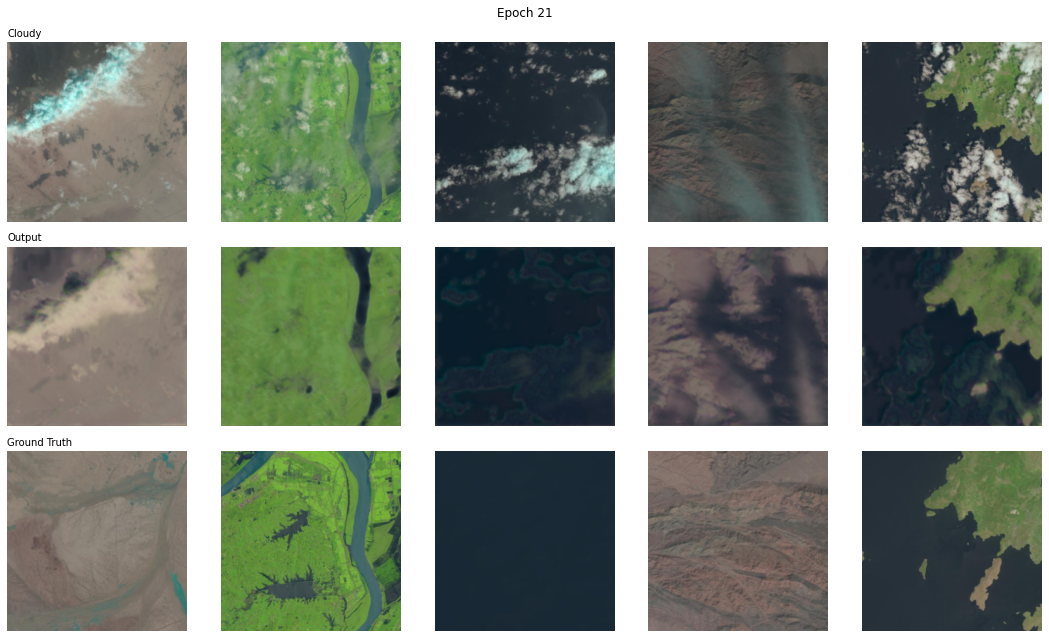

Epoch [21/50] | LR: 1.00e-04 L1: 0.161  0.126 | PSNR: 26.94 | SSIM: 0.8195
Epoch [22/50] | LR: 1.00e-04 L1: 0.159  0.142 | PSNR: 26.26 | SSIM: 0.8236
Epoch [23/50] | LR: 1.00e-04 L1: 0.165  0.121 | PSNR: 25.98 | SSIM: 0.7956
Epoch [24/50] | LR: 1.00e-04 L1: 0.141  0.118 | PSNR: 26.58 | SSIM: 0.8372
Epoch [25/50] | LR: 1.00e-04 L1: 0.144  0.222 | PSNR: 23.55 | SSIM: 0.8027
Epoch [26/50] | LR: 1.00e-04 L1: 0.140  0.123 | PSNR: 26.69 | SSIM: 0.8382
Epoch [27/50] | LR: 1.00e-04 L1: 0.145  0.122 | PSNR: 26.90 | SSIM: 0.8060
Epoch [28/50] | LR: 1.00e-04 L1: 0.139  0.124 | PSNR: 26.50 | SSIM: 0.8336
Epoch [29/50] | LR: 1.00e-04 L1: 0.140  0.188 | PSNR: 24.77 | SSIM: 0.7860
Epoch [30/50] | LR: 1.00e-04 L1: 0.171  0.128 | PSNR: 26.88 | SSIM: 0.8144


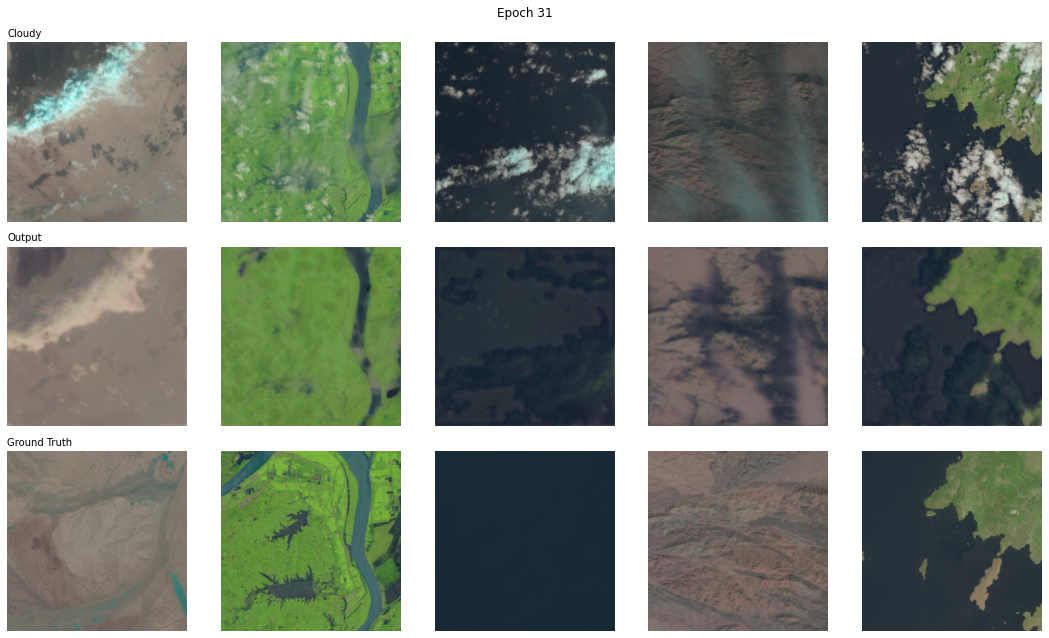

Epoch [31/50] | LR: 1.00e-04 L1: 0.152  0.143 | PSNR: 25.61 | SSIM: 0.8277
Epoch [32/50] | LR: 1.00e-04 L1: 0.133  0.114 | PSNR: 28.05 | SSIM: 0.8484
Epoch [33/50] | LR: 1.00e-04 L1: 0.139  0.155 | PSNR: 25.21 | SSIM: 0.7730
Epoch [34/50] | LR: 1.00e-04 L1: 0.131  0.110 | PSNR: 27.83 | SSIM: 0.8430
Epoch [35/50] | LR: 1.00e-04 L1: 0.130  0.109 | PSNR: 28.51 | SSIM: 0.8448
Epoch [36/50] | LR: 1.00e-04 L1: 0.133  0.123 | PSNR: 26.81 | SSIM: 0.8455
Epoch [37/50] | LR: 1.00e-04 L1: 0.154  0.156 | PSNR: 25.33 | SSIM: 0.7837
Epoch [38/50] | LR: 1.00e-04 L1: 0.156  0.116 | PSNR: 27.02 | SSIM: 0.8382
Epoch [39/50] | LR: 1.00e-04 L1: 0.138  0.126 | PSNR: 26.44 | SSIM: 0.8362
Epoch [40/50] | LR: 1.00e-04 L1: 0.141  0.127 | PSNR: 26.82 | SSIM: 0.8477


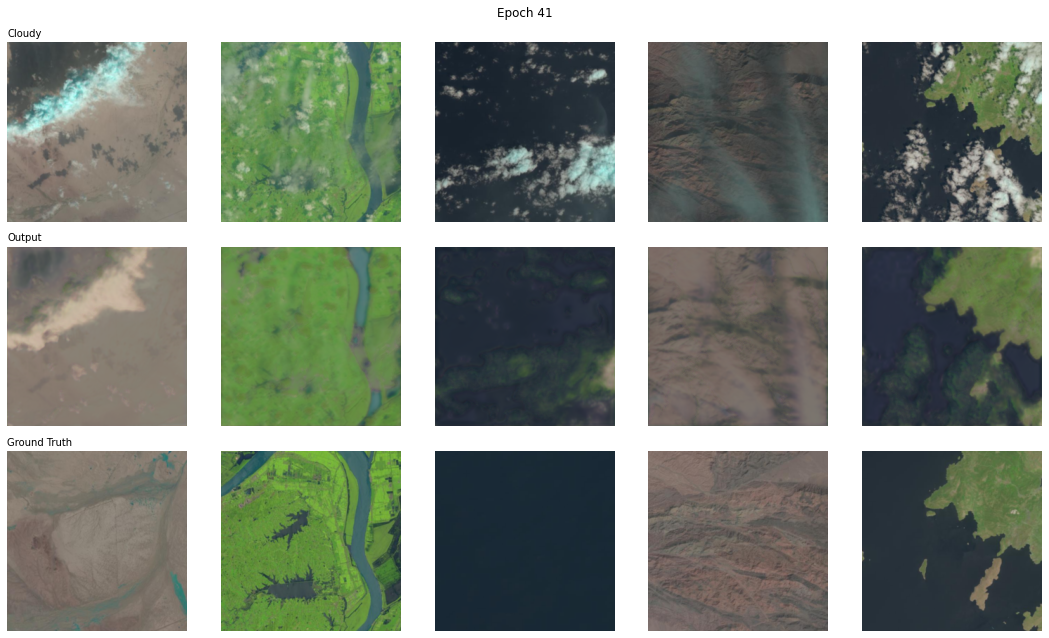

Epoch [41/50] | LR: 1.00e-04 L1: 0.145  0.105 | PSNR: 27.92 | SSIM: 0.8510
Epoch [42/50] | LR: 1.00e-04 L1: 0.149  0.120 | PSNR: 26.76 | SSIM: 0.8478
Epoch [43/50] | LR: 1.00e-04 L1: 0.141  0.132 | PSNR: 25.63 | SSIM: 0.8296
Epoch [44/50] | LR: 1.00e-04 L1: 0.136  0.142 | PSNR: 25.47 | SSIM: 0.8098
Epoch [45/50] | LR: 1.00e-04 L1: 0.131  0.110 | PSNR: 27.79 | SSIM: 0.8507
Epoch [46/50] | LR: 1.00e-04 L1: 0.133  0.114 | PSNR: 27.94 | SSIM: 0.8490
Epoch [47/50] | LR: 1.00e-04 L1: 0.132  0.119 | PSNR: 26.24 | SSIM: 0.8061


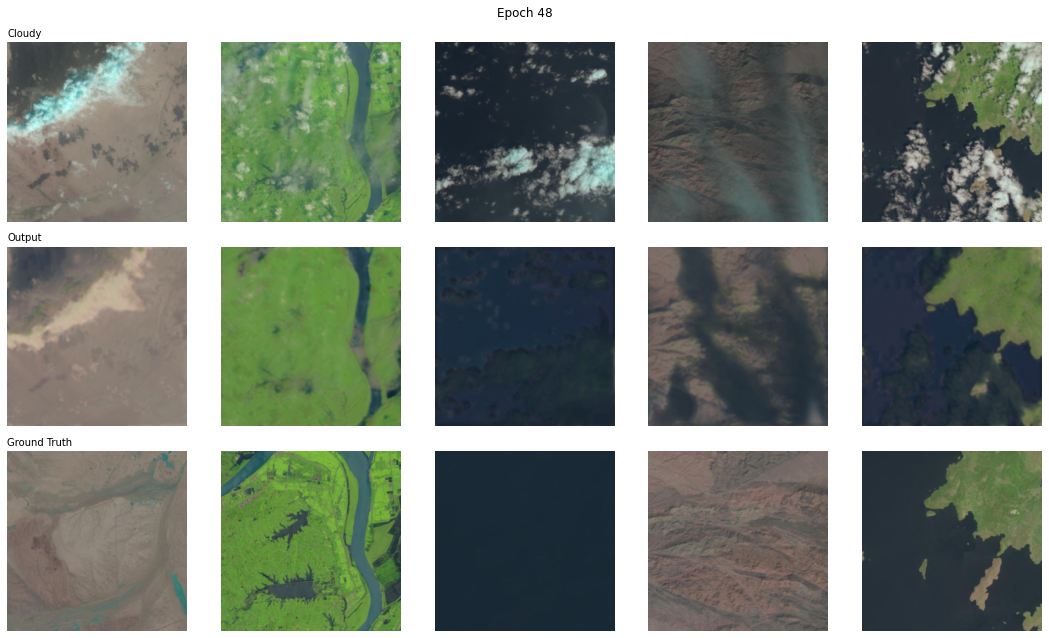

Epoch [48/50] | LR: 1.00e-04 L1: 0.136  0.111 | PSNR: 27.49 | SSIM: 0.8530


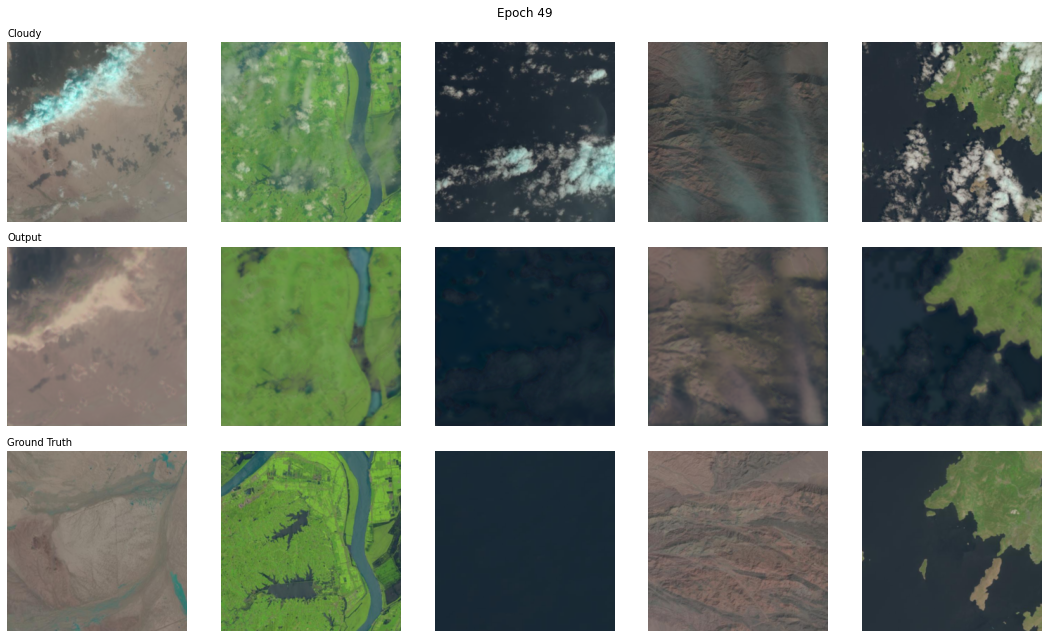

Epoch [49/50] | LR: 1.00e-04 L1: 0.127  0.119 | PSNR: 27.52 | SSIM: 0.8236


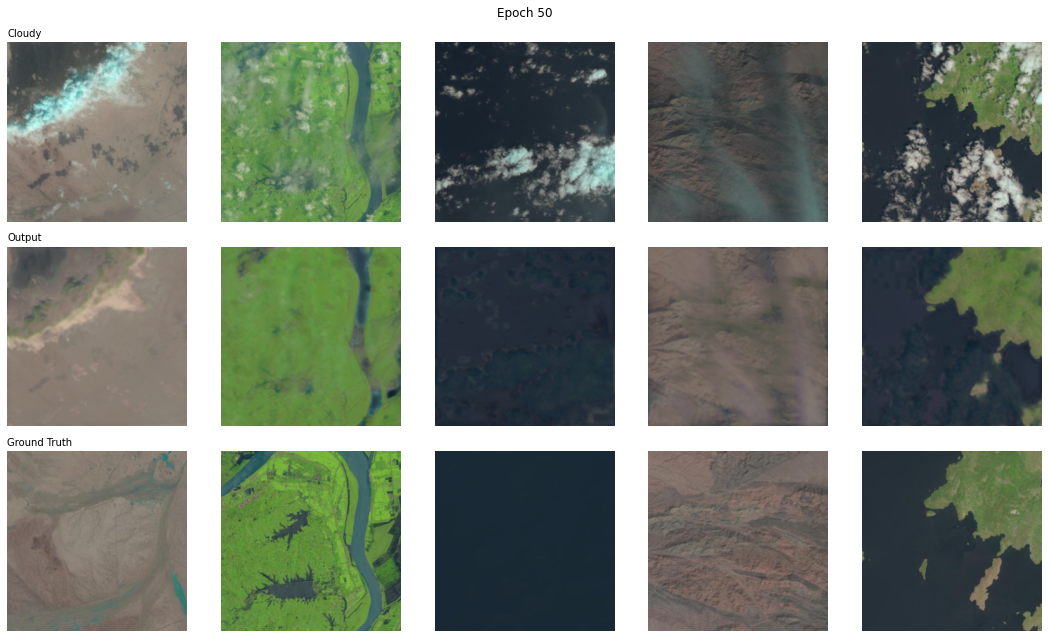

Epoch [50/50] | LR: 1.00e-04 L1: 0.125  0.114 | PSNR: 27.92 | SSIM: 0.8466
Bestes Modell bei Epoch 48 mit SSIM 0.8530 und PSNR 27.49 dB


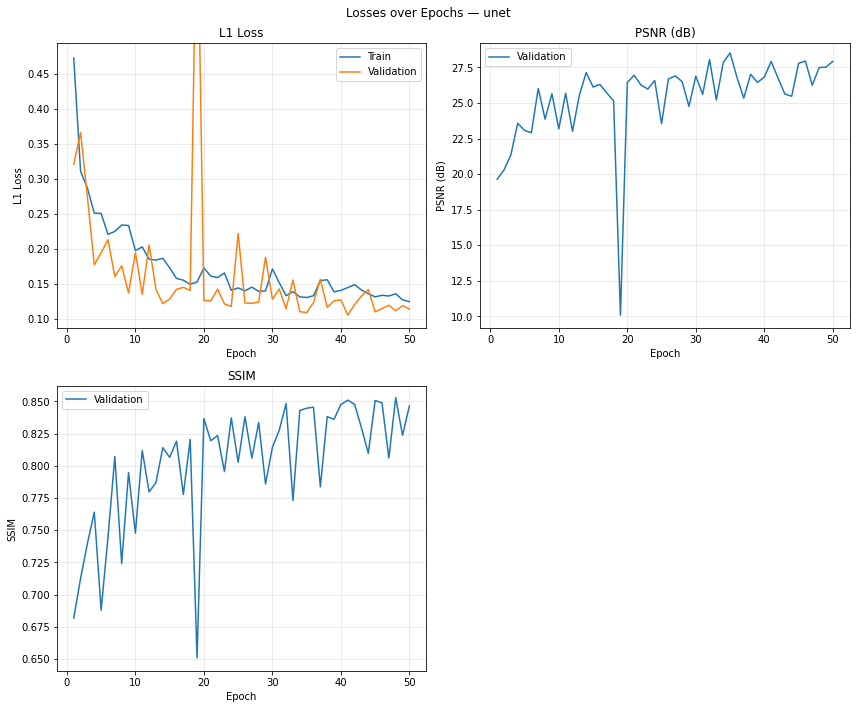

The training took 530.52 seconds with 10.61 seconds per epoch


In [10]:
os.makedirs("checkpoints", exist_ok=True)

start_time = time.time()

for epoch in range(num_epochs):
    generator.train()
    epoch_loss = []

    for cloudy, label, mask in train_dataloader:
        cloudy = cloudy.to(device)
        label = label.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()
        if use_masks:
            output_gen = generator(torch.cat((cloudy, mask), dim=1))
        else:
            output_gen = generator(cloudy)

        loss_recon = l1(output_gen, label)
        if use_masks:
            loss_recon_masked = weighted_l1_loss(output_gen, label, mask, extra=w_extra)
        else:
            loss_recon_masked = 0
        loss = loss_recon + w_factor * loss_recon_masked
        loss.backward()
        optimizer.step()

        epoch_loss.append(loss.item())

    train_losses.append(sum(epoch_loss) / len(epoch_loss))

    if scheduler is not None:
        scheduler.step()

    # ---- Validation ----
    generator.eval()
    gen_val_loss = 0
    psnr_total = 0.0
    ssim_total = 0.0
    n_images = 0

    with torch.no_grad():
        for cloudy, target, mask in val_dataloader:
            cloudy = cloudy.to(device)
            target = target.to(device)
            mask = mask.to(device)

            if use_masks:
                output_gen = generator(torch.cat((cloudy, mask), dim=1))
            else:
                output_gen = generator(cloudy)

            gen_val_loss += (
                l1(output_gen, target)
                + w_factor * weighted_l1_loss(output_gen, target, mask, extra=w_extra)
            ).item()

            # PSNR / SSIM pro Bild
            for i in range(output_gen.size(0)):
                out_np = to_img(output_gen[i])
                gt_np = to_img(target[i])
                psnr_total += psnr_fn(gt_np, out_np, data_range=1.0)
                ssim_total += compute_ssim(gt_np, out_np)
                n_images += 1

    val_losses.append(gen_val_loss / len(val_dataloader))
    val_psnrs.append(psnr_total / n_images)
    val_ssims.append(ssim_total / n_images)

    score = val_ssims[-1]
    if score > best_score:
        torch.save(
            {
                "epoch": epoch,
                "generator": generator.state_dict(),
            },
            "checkpoints/unet/best.pt",
        )
        best_score = score
        best_psnr = val_psnrs[-1]

    # ---- Sample-Outputs: regelmäßig zeigen, letzte paar Epochen speichern ----
    save_path = None
    if epoch >= num_epochs - save_last_n_samples:
        save_path = f"checkpoints/unet/samples_epoch{epoch + 1}.png"
    if epoch % plot_every == 0 or epoch >= num_epochs - save_last_n_samples:
        plot_samples_gan(
            generator,
            fixed_batch,
            device,
            epoch,
            save_path=save_path,
            use_masks=use_masks,
        )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | LR: {optimizer.param_groups[0]['lr']:.2e} "
        f"L1: {train_losses[-1]:.3f}  {val_losses[-1]:.3f} | "
        f"PSNR: {val_psnrs[-1]:.2f} | SSIM: {val_ssims[-1]:.4f}"
    )

print(
    f"Bestes Modell bei Epoch {torch.load('checkpoints/unet/best.pt', map_location=device)['epoch'] + 1} "
    f"mit SSIM {best_score:.4f} und PSNR {best_psnr:.2f} dB"
)
# ----------------------------------------------------------------------
# Nach dem Training: Plots speichern
# ----------------------------------------------------------------------
plot_losses(
    {
        "L1 Loss": (train_losses, val_losses),
        "PSNR (dB)": (None, val_psnrs),
        "SSIM": (None, val_ssims),
    },
    model_name="unet",
    ncols=2,
    save_path="checkpoints/unet/metrics.png",
)

duration = time.time() - start_time
print(
    f"The training took {duration:.2f} seconds "
    f"with {duration / num_epochs:.2f} seconds per epoch"
)

Bestes Modell aus Epoch 48 geladen.
TEST  PSNR: 27.55 dB | SSIM: 0.8435  (über 148 Bilder)


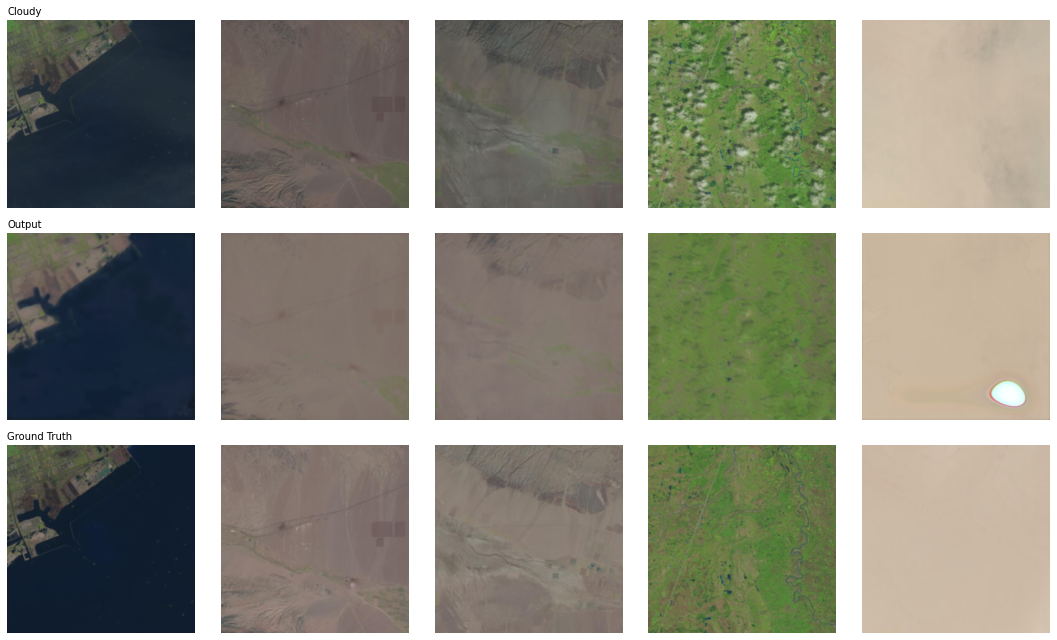

In [ ]:
import matplotlib.pyplot as plt

ckpt = torch.load("checkpoints/unet/best.pt", map_location=device)
generator.load_state_dict(ckpt["generator"])
generator.eval()
print(f"Bestes Modell aus Epoch {ckpt['epoch'] + 1} geladen.")

# ---- Metriken über das ganze Test-Set ----
psnr_total, ssim_total, n = 0.0, 0.0, 0
with torch.no_grad():
    for cloudy, target, mask in test_dataloader:
        cloudy, target, mask = cloudy.to(device), target.to(device), mask.to(device)
        if use_masks:
            output_gen = generator(torch.cat((cloudy, mask), dim=1))
        else:
            output_gen = generator(cloudy)
        for i in range(output_gen.size(0)):
            out_np, gt_np = to_img(output_gen[i]), to_img(target[i])
            psnr_total += psnr_fn(gt_np, out_np, data_range=1.0)
            ssim_total += compute_ssim(gt_np, out_np)
            n += 1

test_psnr = psnr_total / n
test_ssim = ssim_total / n
print(f"TEST  PSNR: {test_psnr:.2f} dB | SSIM: {test_ssim:.4f}  (über {n} Bilder)")


plot_test_samples(
    generator,
    test_dataloader,
    device,
    n_show=5,
    save_path="checkpoints/unet/test_samples.png",
    use_masks=use_masks,
)